# Filtros - 01.Preparação

Nesse notebook descrevemos as ferramentas básicas para trabalhar com imagens em Python. Nosso objetivo é comparar a ação de diferentes filtros sobre uma imagem com ruido, como mostrado no artigo de Shuman, Narang, Frossard, Ortega e Vandergheynst, IEEE Signals Processing Magazine 2013.

Usaremos a biblioteca Pillow, sucessora da PIL (Python Imaging Library). Podem ver um excelente tutorial [aqui](https://realpython.com/image-processing-with-the-python-pillow-library/#image-processing-using-pillow-in-python).

In [67]:
from PIL import Image, ImageFilter
import numpy as np

Agora, vamos abrir uma foto mostrando o momento em que Fernando Morena faz, no minuto 90, o gol que deu a Libertadores a Peñarol em 1982. O Python deve abrir a imagem no seu visualizador padrão.

In [68]:
# Abrir a imagem
img = Image.open('GolDeMorena.jpg')
img.show()

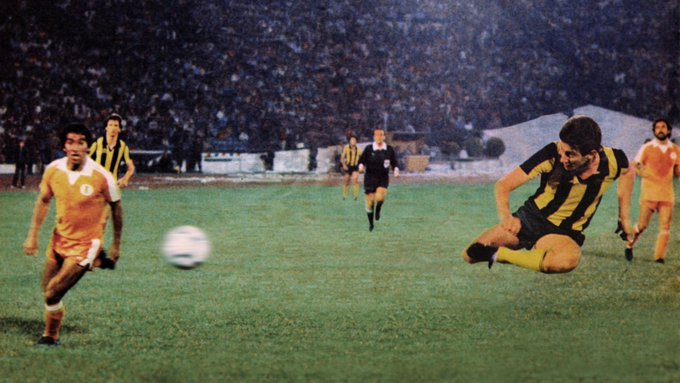

Vamos ver o tamanho e tipo da imagem.

In [69]:
img.size

(680, 383)

In [70]:
img.mode

'RGB'

A imagem está em RGB, o que complicaria um pouco o nosso trabalho. Não vou entrar em detalhes técnicos, mas queremos a imagem em grayscale, i.e. cada pixel
contem um inteiro em [0,255]. Isso facilita nosso trabalho. Então

In [71]:
# Converter a grayscale
img_gray_Morena = img.convert('L')

Vamos verificar.

In [72]:
img_gray_Morena.mode

'L'

In [73]:
img_gray_Morena.show()

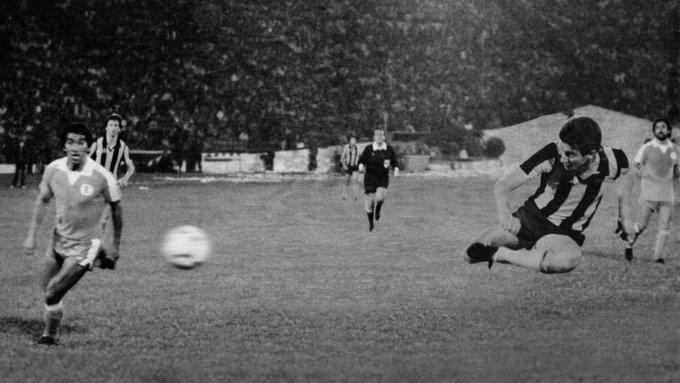

Agora vamos criar um array com a imagem e ver seu conteúdo.

In [74]:
# Criar array da imagem e verificar conteúdo
array_gray_Morena = np.array(img_gray_Morena)
print(array_gray_Morena)

[[ 11  10   8 ...  39  35  38]
 [ 12  11   9 ...  36  30  30]
 [ 14  12  10 ...  38  30  30]
 ...
 [104 103  99 ...  78  78  77]
 [100  99  94 ...  80  81  82]
 [ 96  94  89 ...  85  87  87]]


Agora que a imagem é um array, podemos manipulá-la. Por exemplo, vou sujar a imagem com um ruido Gaussiano e ver o array.

In [75]:
array_gray_Morena_noisy = array_gray_Morena+np.random.normal(0,10, size=(383, 680))
print(array_gray_Morena_noisy)

[[-13.19997832  11.079376     8.02490392 ...  60.60080871  24.91557447
   35.47599523]
 [ -3.23091253  17.26573869   7.98432415 ...  45.95873     46.0810157
   29.20930529]
 [ 12.7514142    5.01096025  14.14561477 ...  35.96269833  35.6324283
   12.87253175]
 ...
 [109.18829071 104.14618488 105.62599359 ...  53.89344487  76.88185451
   85.7878508 ]
 [114.43360156  91.23235368  89.41078141 ...  78.13703332  96.86545541
   89.0816849 ]
 [ 96.53772553  82.44079865  69.72541351 ...  85.16032594  67.49916486
   69.28351556]]


Para poder continuar trabalhando devemos voltar a pixels inteiros. 

In [76]:
array_gray_Morena_noisy = array_gray_Morena_noisy.astype(np.uint8)

Para ver a imagem com ruido, devemos passar do array para imagem.

In [77]:
img_gray_Morena_noisy = Image.fromarray(array_gray_Morena_noisy, 'L') 


In [78]:
img_gray_Morena_noisy.show()

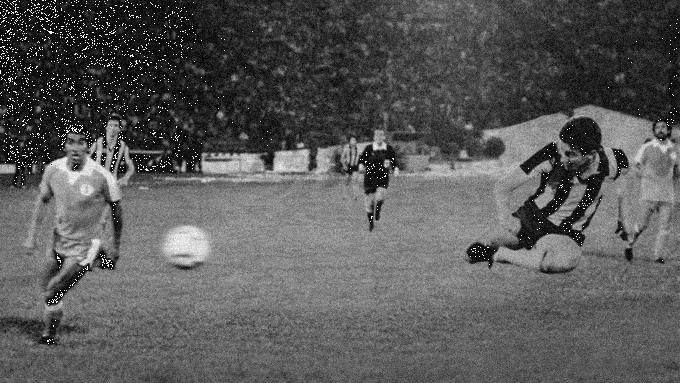

Finalmente, vamos guardar a imagem com ruido.

In [79]:
img_gray_Morena_noisy.save('GOlDeMorena_cinza_ruido.jpg')

Portanto, temos vértices (pixels) e um sinal (imagem no array). Agora precisamos definir o grafo (arestas) para poder começar a filtrar nossa imagem. Recomendo fazer uma revisão dos tutoriais onde é descrito como construir um grafo a partir de um array, como fazer GFT, como criar um filtro, etc. 